##Customer Segmentation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Import Libraries

In [ ]:
# Import necessary library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

###Load and Inspect the Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Tech crush/Mall_Customers.csv')

# Preview the data
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Shape of the data
df.shape

(200, 5)

In [ ]:
# Column names and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# Summary statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# Check missing values
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


###Visualization to Understand Distribution

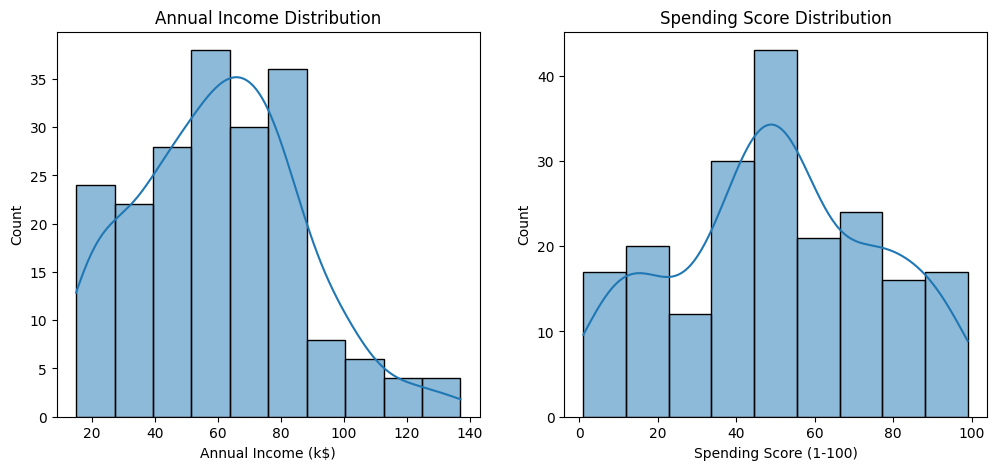

In [ ]:
# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title('Annual Income Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title('Spending Score Distribution')

plt.show()

###Feature Selection and Scaling

In [ ]:
# Select feature
x = df[['Annual Income (k$)','Spending Score (1-100)']]

# View selected feature
x.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
# Select the scaling method
scaler = StandardScaler()

# Apply standard scaling
x_scaled = scaler.fit_transform(x)

# View scaled data
x_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

###Determine Optimum Number of Cluster

In [ ]:
# Finding optimal k

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=234)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

# View wcss
wcss

[399.99999999999994,
 270.70426664306717,
 195.2466301907915,
 108.92131661364358,
 65.56840815571681,
 55.057348270385965,
 46.80995783413118,
 42.871289711022854,
 32.406659676456606,
 30.028327639008264]

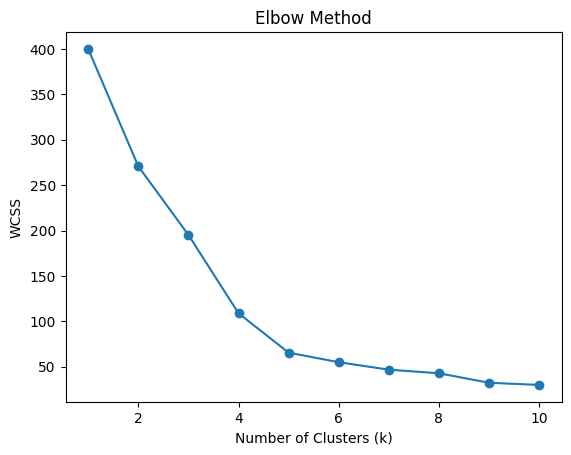

In [ ]:
# Plot Elbow Curve to see what the kmeans selects as the best clusters within the 1-11 range of the dataset
plt.plot(range(1, 11), wcss, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

###Train K-Means Model

In [ ]:
# Train model
kmeans = KMeans(n_clusters=5, random_state=42) #No. of cluster is 5 based on the elbow bent
clusters = kmeans.fit_predict(x_scaled)

df['Cluster'] = clusters    # This creates a new column 'Clusters' in our dataset

# View cluster
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


###Visualize the Clusters

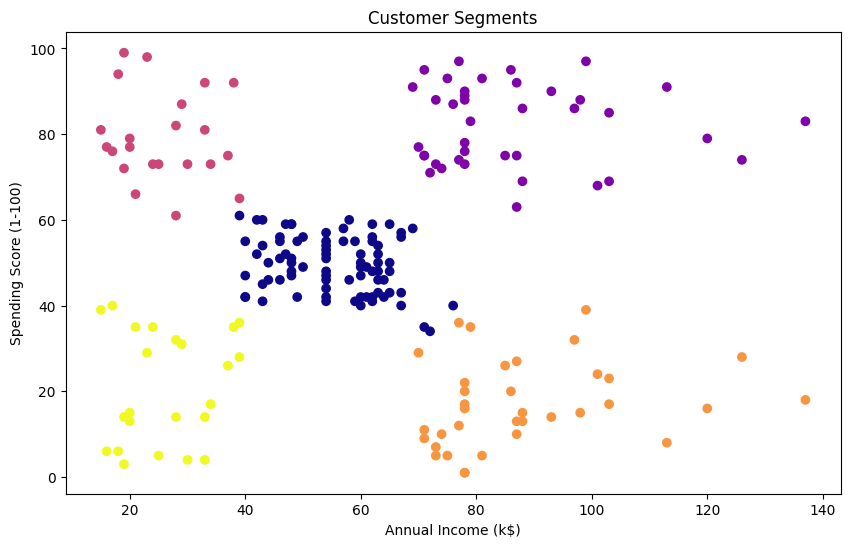

In [ ]:
# Visualize the cluster
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'],
             cmap='plasma')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.show()

###Profile Numerical Cluster

In [ ]:
# Add cluster mean
df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
# cluster size (To know no. of customers in each of the 5 clusters)
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


###Model Evaluation

In [ ]:
''' Sihouette score of less than 0.5 means its not a good cluster,
but Sihouette score of more than 0.5 means it is a good cluster.
However Sihouette score of 0.9-1.0 is too perfect of a result which is
impossible except if the data are synthetic. Real world data isn't that perfect '''

#Evaluate (the model for the clustering) using silhouette
score = silhouette_score(x_scaled, df['Cluster'])
print('Silhouette Score:', score)

Silhouette Score: 0.5546571631111091


###Anomaly Detection

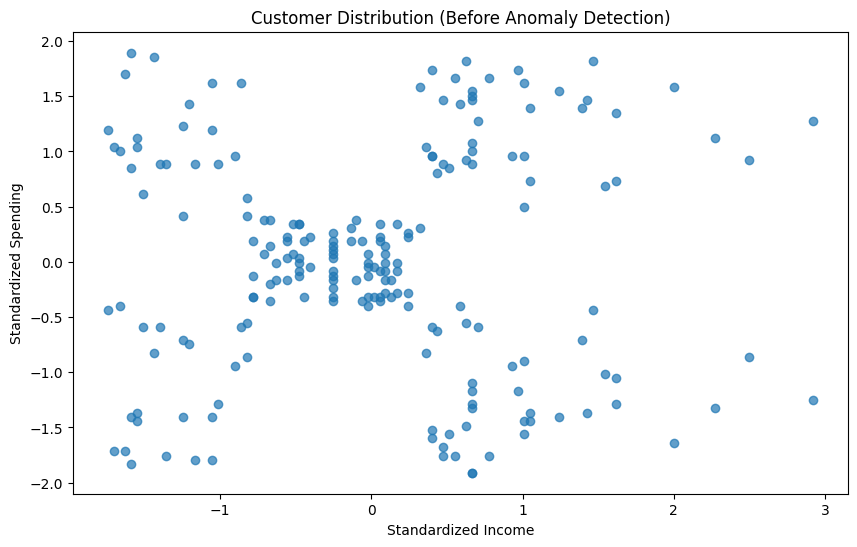

In [ ]:
# Visualizing the data first before anomaly detection
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(x_scaled[:, 0],
            x_scaled[:, 1],
            alpha = 0.7)
plt.xlabel('Standardized Income')
plt.ylabel('Standardized Spending')
plt.title('Customer Distribution (Before Anomaly Detection)')
plt.show()

###Isolation Forest

In [ ]:
'''N/B: Aside from isolation forest, DBSCAN, and Local outlier factor
can also be used for anomalies detection.

Also note that in Isolation Forest, -1 indicates anomalies while 1 indicates normal'''


from sklearn.ensemble import IsolationForest

# Define the model
iso = IsolationForest(
    n_estimators=100,      # Number of trees (The more trees, the more stable)
    contamination=0.05,    # Assume 5% anomalies and adjusted later accordingly
    random_state=42)

# Fit the model
iso.fit(x_scaled)

# Predict anomalies
y_iso = iso.predict(x_scaled)

# Add to dataframe
df['Anomaly_iso'] = y_iso

# View the anomalies
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Anomaly_iso
0,1,Male,19,15,39,4,1
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,4,1
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,4,1
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,-1
196,197,Female,45,126,28,3,-1
197,198,Male,32,126,74,1,-1
198,199,Male,32,137,18,3,-1


In [ ]:
# anomaly count
df['Anomaly_iso'].value_counts()

,count
Anomaly_iso,
1,190
-1,10


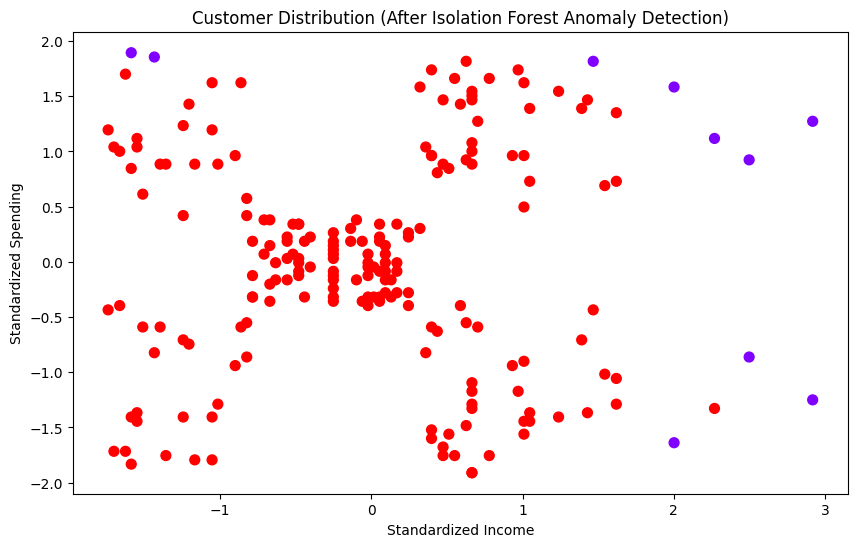

In [ ]:
# Visualize Anomaly
plt.figure(figsize=(10, 6))
plt.scatter(x_scaled[:, 0],
            x_scaled[:, 1],
            c=df['Anomaly_iso'],
            cmap = 'rainbow',
            s=50)
plt.xlabel('Standardized Income')
plt.ylabel('Standardized Spending')
plt.title('Customer Distribution (After Isolation Forest Anomaly Detection)')
plt.show()

In [ ]:
# Compute anomaly indices ( This is just to add them back to the dataframe)
Anomalies = df[df['Anomaly_iso'] == -1]

In [ ]:
# Inspect or fish out the customer rows with the anomalies
Anomalies[['Annual Income (k$)', 'Spending Score (1-100)']]

,Annual Income (k$),Spending Score (1-100)
11,19,99
19,23,98
185,99,97
192,113,8
193,113,91
195,120,79
196,126,28
197,126,74
198,137,18
199,137,83
